# EDA & Feature Engineering — Dislog PFE

**Objective**: Connect to the SQL Server data warehouse, explore all star tables, build RFM features, perform customer behavior analysis, and produce statistical summaries and visualizations (Phase 2).

---

## Table of Contents

1. [Setup & DB Connection](#1)
2. [Exploratory Data Analysis on All Tables](#2)
3. [Build RFM Features](#3)
4. [Customer Behavior Analysis](#4)
5. [Statistical Summaries and Distributions](#5)
6. [Visualizations](#6)
7. [Conclusion & Next Steps](#7)

<a id='1'></a>
## 1. Setup & DB Connection

Add project root to path, load environment variables, connect to SQL Server, and load all 8 star tables.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

# Project root (parent of notebooks/)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
load_dotenv(PROJECT_ROOT / '.env')

from src.config import get_sqlserver_connection_string

# Plot style (match 01_data_profiling)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

engine = create_engine(get_sqlserver_connection_string())
print('Database connection OK.')

Database connection OK.


In [2]:
# ── Dimension tables (small — load all at once) ──────────────────────────────
df_dim_date      = pd.read_sql('SELECT * FROM DimDate', engine)
df_dim_customer  = pd.read_sql('SELECT * FROM DimCustomer', engine)
df_dim_seller    = pd.read_sql('SELECT * FROM DimSeller', engine)
df_dim_product   = pd.read_sql('SELECT * FROM DimProduct', engine)
df_dim_promotion = pd.read_sql('SELECT * FROM DimPromotion', engine)
df_dim_payment   = pd.read_sql('SELECT * FROM DimPaymentMethod', engine)

print('Dimensions loaded:')
for name, df in [('DimDate', df_dim_date), ('DimCustomer', df_dim_customer),
                 ('DimSeller', df_dim_seller), ('DimProduct', df_dim_product),
                 ('DimPromotion', df_dim_promotion), ('DimPaymentMethod', df_dim_payment)]:
    print(f'  {name}: {len(df):,} rows')

Dimensions loaded:
  DimDate: 388 rows
  DimCustomer: 87,653 rows
  DimSeller: 410 rows
  DimProduct: 2,320 rows
  DimPromotion: 4 rows
  DimPaymentMethod: 3 rows


In [3]:
import gc

print('Loading FactSales...')
chunks = []
for chunk in pd.read_sql('SELECT * FROM FactSales', engine, chunksize=500_000):
    chunks.append(chunk)
    print(f'  {sum(len(c) for c in chunks):,} rows loaded...')

df_fact_sales = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()
print(f'Done. FactSales: {len(df_fact_sales):,} rows')

Loading FactSales...
  500,000 rows loaded...
  1,000,000 rows loaded...
  1,500,000 rows loaded...
  2,000,000 rows loaded...
  2,500,000 rows loaded...
  3,000,000 rows loaded...
  3,500,000 rows loaded...
  4,000,000 rows loaded...
  4,500,000 rows loaded...
  5,000,000 rows loaded...
  5,500,000 rows loaded...
  6,000,000 rows loaded...
  6,500,000 rows loaded...
  7,000,000 rows loaded...
  7,500,000 rows loaded...
  8,000,000 rows loaded...
  8,500,000 rows loaded...
  9,000,000 rows loaded...
  9,229,070 rows loaded...
Done. FactSales: 9,229,070 rows


In [4]:
# ── FactInvoices (~1.4M rows) ────────────────────────────────────────────────
print('Loading FactInvoices...')
df_fact_invoices = pd.read_sql('SELECT * FROM FactInvoices', engine)
print(f'  FactInvoices: {len(df_fact_invoices):,} rows | RAM: {df_fact_invoices.memory_usage(deep=True).sum() / 1e9:.2f} GB')

Loading FactInvoices...
  FactInvoices: 1,437,421 rows | RAM: 0.16 GB


<a id='2'></a>
## 2. Exploratory Data Analysis on All Tables

For each dimension and fact table: shape, dtypes, sample, describe, null counts, and distinct key counts. Then check date ranges and FK sanity.

In [5]:
from IPython.display import display, HTML
import pandas as pd
import numpy as np


# ─────────────────────────────────────────────────────────────────────────────
#  Shared helpers
# ─────────────────────────────────────────────────────────────────────────────
_BLUE   = "#2E75B6"
_STRIPE = "#f2f7fc"

def _styled_table(df_input):
    """DataFrame → styled HTML table with alternating rows and index column."""
    rows = "<thead><tr style=\'background:#2E75B6; color:white;\'>"
    rows += "<th style=\'padding:7px 14px; font-size:13px; font-weight:600; text-align:left;\'>#</th>"
    for col in df_input.columns:
        rows += f"<th style=\'padding:7px 14px; font-size:13px; font-weight:600; text-align:left;\'>{col}</th>"
    rows += "</tr></thead><tbody>"
    for i, (_, row) in enumerate(df_input.iterrows()):
        bg = "white" if i % 2 == 0 else _STRIPE
        rows += f"<tr style=\'background:{bg};\'>"
        rows += f"<td style=\'padding:6px 14px; font-size:13px; color:#888; border-bottom:1px solid #dde4ed;\'>{i}</td>"
        for val in row:
            rows += f"<td style=\'padding:6px 14px; font-size:13px; color:#1a1a1a; border-bottom:1px solid #dde4ed;\'>{val}</td>"
        rows += "</tr>"
    rows += "</tbody>"
    return f"<table style=\'border-collapse:collapse; width:100%; margin-bottom:20px;\'>{rows}</table>"

def _section_label(text):
    return (
        f"<div style=\"font-family:Calibri,\'Segoe UI\',sans-serif; "
        f"font-size:11px; font-weight:700; color:{_BLUE}; "
        f"letter-spacing:0.7px; text-transform:uppercase; margin-bottom:7px;\">"
        f"{text}</div>"
    )

def _title_banner(name, nrows, ncols):
    return (
        f"<div style=\"background:{_BLUE}; padding:10px 16px; margin-bottom:18px;\">"
        f"<div style=\"font-family:Calibri,\'Segoe UI\',sans-serif; font-size:17px; font-weight:700; color:#ffffff;\">{name}</div>"
        f"<div style=\"font-family:Calibri,\'Segoe UI\',sans-serif; font-size:12px; color:#cce3f5; margin-top:3px;\">"
        f"{nrows:,} rows &nbsp;·&nbsp; {ncols} columns</div></div>"
    )

def _col_overview(df, nulls, null_pct):
    html = _section_label("Column Overview")
    html += (
        f"<table style=\"border-collapse:collapse; width:100%; margin-bottom:20px;\">"
        f"<thead><tr style=\"background:{_BLUE}; color:white;\">"
        f"<th style=\"padding:7px 14px; font-size:13px; font-weight:600; text-align:left;\">Column</th>"
        f"<th style=\"padding:7px 14px; font-size:13px; font-weight:600; text-align:left;\">Type</th>"
        f"<th style=\"padding:7px 14px; font-size:13px; font-weight:600; text-align:left;\">Nulls</th>"
        f"<th style=\"padding:7px 14px; font-size:13px; font-weight:600; text-align:left;\">Null %</th>"
        f"</tr></thead><tbody>"
    )
    for i, col in enumerate(df.columns):
        bg = "white" if i % 2 == 0 else _STRIPE
        nc = "#C00000" if nulls[col] > 0 else "#375623"
        html += (
            f"<tr style=\"background:{bg};\">"
            f"<td style=\"padding:6px 14px; font-size:13px; color:#1a1a1a; border-bottom:1px solid #dde4ed;\">{col}</td>"
            f"<td style=\"padding:6px 14px; font-size:13px; color:#555;    border-bottom:1px solid #dde4ed;\">{df[col].dtype}</td>"
            f"<td style=\"padding:6px 14px; font-size:13px; color:{nc}; border-bottom:1px solid #dde4ed;\">{nulls[col]:,}</td>"
            f"<td style=\"padding:6px 14px; font-size:13px; color:{nc}; border-bottom:1px solid #dde4ed;\">{null_pct[col]}%</td>"
            f"</tr>"
        )
    html += "</tbody></table>"
    return html


# ─────────────────────────────────────────────────────────────────────────────
#  profile_dataframe  — for Dim* tables
# ─────────────────────────────────────────────────────────────────────────────
def profile_dataframe(name, df):
    nulls    = df.isnull().sum()
    null_pct = (nulls / len(df) * 100).round(1)
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    html = f"<div style=\"font-family:Calibri,\'Segoe UI\',sans-serif; margin:32px 0 24px 0; max-width:1100px;\">"
    html += _title_banner(name, df.shape[0], df.shape[1])
    html += _col_overview(df, nulls, null_pct)
    html += _section_label("Sample Rows (first 5)")
    html += _styled_table(df.head())
    if num_cols:
        html += _section_label("Numeric Summary")
        html += _styled_table(df[num_cols].describe().round(2).reset_index().rename(columns={"index": "stat"}))
    html += "</div><hr style=\'border:none; border-top:1px solid #dde4ed; margin:4px 0 0 0;\'>"
    display(HTML(html))


# ─────────────────────────────────────────────────────────────────────────────
#  profile_fact_table  — for Fact* tables
# ─────────────────────────────────────────────────────────────────────────────
def profile_fact_table(name, df, distinct_checks: dict):
    """
    distinct_checks: {col: label}  e.g. {'SaleID': 'Distinct SaleID'}
    Adds a Key Metrics card row above Column Overview.
    """
    nulls    = df.isnull().sum()
    null_pct = (nulls / len(df) * 100).round(1)
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    html = f"<div style=\"font-family:Calibri,\'Segoe UI\',sans-serif; margin:32px 0 24px 0; max-width:1100px;\">"
    html += _title_banner(name, df.shape[0], df.shape[1])

    # Key Metrics cards
    if distinct_checks:
        html += _section_label("Key Metrics")
        html += "<div style=\"display:flex; gap:16px; margin-bottom:20px; flex-wrap:wrap;\">"
        for col, label in distinct_checks.items():
            count = df[col].nunique()
            html += (
                f"<div style=\"background:{_STRIPE}; border:1px solid #dde4ed; border-top:3px solid {_BLUE}; "
                f"padding:12px 20px; min-width:160px;\">"
                f"<div style=\"font-size:11px; color:#888; text-transform:uppercase; letter-spacing:0.5px; margin-bottom:4px;\">{label}</div>"
                f"<div style=\"font-size:22px; font-weight:700; color:#1a1a1a;\">{count:,}</div>"
                f"</div>"
            )
        html += "</div>"

    html += _col_overview(df, nulls, null_pct)
    html += _section_label("Sample Rows (first 5)")
    html += _styled_table(df.head())
    if num_cols:
        html += _section_label("Numeric Summary")
        html += _styled_table(df[num_cols].describe().round(2).reset_index().rename(columns={"index": "stat"}))
    html += "</div><hr style=\'border:none; border-top:1px solid #dde4ed; margin:4px 0 0 0;\'>"
    display(HTML(html))


# ── Dim tables ────────────────────────────────────────────────────────────────
for _name, _df in [
    ('DimDate',          df_dim_date),
    ('DimCustomer',      df_dim_customer),
    ('DimSeller',        df_dim_seller),
    ('DimProduct',       df_dim_product),
    ('DimPromotion',     df_dim_promotion),
    ('DimPaymentMethod', df_dim_payment),
]:
    profile_dataframe(_name, _df)


Column,Type,Nulls,Null %
DateKey,int64,0,0.0%
FullDate,object,0,0.0%
Year,int64,0,0.0%
Quarter,int64,0,0.0%
Month,int64,0,0.0%
Day,int64,0,0.0%
DayOfWeek,int64,0,0.0%
DayName,str,0,0.0%
MonthName,str,0,0.0%
IsWeekend,bool,0,0.0%


Column,Type,Nulls,Null %
CustomerKey,int64,0,0.0%
AccountID,str,0,0.0%
AccountName,str,0,0.0%
RegionID,str,192,0.2%
RegionDescription,str,467,0.5%
SectorID,str,317,0.4%
SectorDescription,str,322,0.4%
ValidFrom,object,0,0.0%
ValidTo,object,"87,653",100.0%
IsCurrent,bool,0,0.0%


In [6]:
# ── Fact tables ───────────────────────────────────────────────────────────────
profile_fact_table(
    'FactSales', df_fact_sales,
    distinct_checks={
        'SaleID':      'Distinct SaleID',
        'CustomerKey': 'Distinct CustomerKey',
        'SellerKey':   'Distinct SellerKey',
        'ProductKey':  'Distinct ProductKey',
    }
)

profile_fact_table(
    'FactInvoices', df_fact_invoices,
    distinct_checks={
        'InvoiceID':   'Distinct InvoiceID',
        'CustomerKey': 'Distinct CustomerKey',
        'SaleID':      'Distinct SaleID',
    }
)


Column,Type,Nulls,Null %
SalesKey,int64,0,0.0%
SaleID,int64,0,0.0%
OrderDateKey,int64,0,0.0%
DeliveryDateKey,int64,0,0.0%
CustomerKey,int64,0,0.0%
SellerKey,int64,0,0.0%
ProductKey,int64,0,0.0%
PromotionKey,int64,0,0.0%
Quantity,int64,0,0.0%
UnitPrice,float64,0,0.0%


In [7]:
# Date range and FK sanity
# OrderDateKey / PaymentDateKey are YYYYMMDD integers
order_keys = df_fact_sales['OrderDateKey'].dropna()
pay_keys = df_fact_invoices['PaymentDateKey'].dropna()
print('OrderDateKey range:', order_keys.min(), '-', order_keys.max())
print('PaymentDateKey range:', pay_keys.min(), '-', pay_keys.max())

# Sanity: FactSales.CustomerKey in DimCustomer?
cust_keys = set(df_dim_customer['CustomerKey'])
fs_cust = set(df_fact_sales['CustomerKey'].dropna().astype(int))
fi_cust = set(df_fact_invoices['CustomerKey'].dropna().astype(int))
print('FactSales CustomerKeys all in DimCustomer:', fs_cust.issubset(cust_keys))
print('FactInvoices CustomerKeys all in DimCustomer:', fi_cust.issubset(cust_keys))

OrderDateKey range: 20240101 - 20241231
PaymentDateKey range: 20240101 - 20241231
FactSales CustomerKeys all in DimCustomer: True
FactInvoices CustomerKeys all in DimCustomer: True


<a id='3'></a>
## 3. Build RFM Features

One row per customer (CustomerKey). **R**ecency = days since last order, **F**requency = number of distinct orders, **M**onetary = total amount spent. Reference date = max order date in the data.

In [8]:
# Reference date: latest order date in FactSales (DateKey is YYYYMMDD)
max_date_key = int(df_fact_sales['OrderDateKey'].max())
ref_date = pd.to_datetime(str(max_date_key), format='%Y%m%d').date()

# Customer-level aggregates from FactSales
agg_sales = df_fact_sales.groupby('CustomerKey').agg(
    last_order_date_key=('OrderDateKey', 'max'),
    order_count=('SaleID', 'nunique'),
    total_amount=('LineTotalAmount', 'sum')
).reset_index()

# Convert last OrderDateKey to date and compute Recency (days since last order)
agg_sales['last_order_date'] = pd.to_datetime(agg_sales['last_order_date_key'].astype(str), format='%Y%m%d').dt.date
agg_sales['Recency']   = (ref_date - agg_sales['last_order_date']).apply(lambda x: x.days)
agg_sales['Frequency'] = agg_sales['order_count']
agg_sales['Monetary']  = agg_sales['total_amount']

df_rfm = agg_sales[['CustomerKey', 'Recency', 'Frequency', 'Monetary']].copy()

profile_fact_table(
    f'RFM Base Table  (ref date: {ref_date})', df_rfm,
    distinct_checks={'CustomerKey': 'Distinct Customers'}
)


<a id='4'></a>
## 4. Customer Behavior Analysis

Distributions of R, F, M; simple RFM segments (quartiles); top customers by frequency and monetary; breakdowns by Region, Sector, and top products.

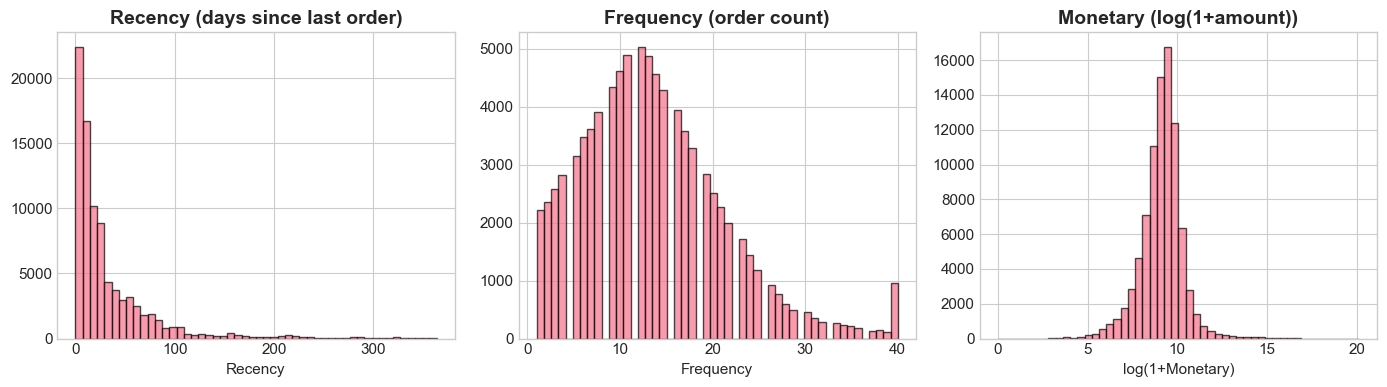

In [9]:
# RFM distributions (histograms)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(df_rfm['Recency'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Recency (days since last order)')
axes[0].set_xlabel('Recency')
axes[1].hist(df_rfm['Frequency'].clip(upper=df_rfm['Frequency'].quantile(0.99)), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Frequency (order count)')
axes[1].set_xlabel('Frequency')
axes[2].hist(np.log1p(df_rfm['Monetary'].dropna()), bins=50, edgecolor='black', alpha=0.7)
axes[2].set_title('Monetary (log(1+amount))')
axes[2].set_xlabel('log(1+Monetary)')
plt.tight_layout()
plt.show()

In [10]:
# Simple RFM segments (quartiles: 1=best, 4=worst for R; 4=best, 1=worst for F and M)
df_rfm['R_quartile'] = pd.qcut(df_rfm['Recency'],                   q=4, labels=[4, 3, 2, 1], duplicates='drop')
df_rfm['F_quartile'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
df_rfm['M_quartile'] = pd.qcut(df_rfm['Monetary'].rank(method='first'),  q=4, labels=[1, 2, 3, 4])
df_rfm['RFM_score']  = df_rfm['R_quartile'].astype(str) + df_rfm['F_quartile'].astype(str) + df_rfm['M_quartile'].astype(str)

# Label segments
def label_segment(row):
    r, f, m = int(row['R_quartile']), int(row['F_quartile']), int(row['M_quartile'])
    if r >= 3 and f >= 3 and m >= 3: return 'Champions'
    if r <= 2 and f <= 2:            return 'Hibernating'
    if r <= 2:                       return 'At risk'
    if f >= 3 and m >= 3:            return 'Loyal'
    return 'Other'
df_rfm['Segment'] = df_rfm.apply(label_segment, axis=1)

# Segment counts
seg_counts = df_rfm['Segment'].value_counts().reset_index()
seg_counts.columns = ['Segment', 'Count']
profile_dataframe('Segment Distribution', seg_counts)

# Mean R/F/M by segment
seg_stats = (
    df_rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']]
    .mean().round(2).reset_index()
)
profile_dataframe('Mean R/F/M by Segment', seg_stats)


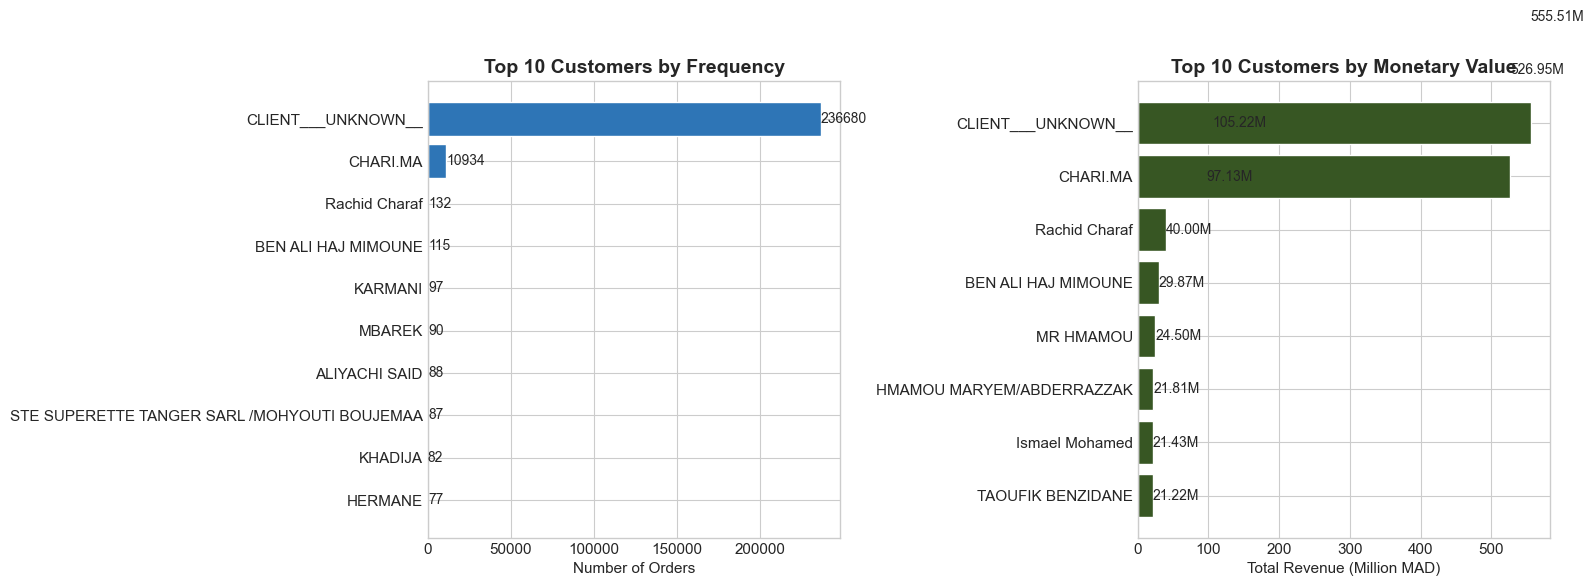

In [11]:
# Top customers by Frequency and by Monetary
rfm_cust = df_rfm.merge(
    df_dim_customer[['CustomerKey', 'AccountID', 'AccountName', 'RegionDescription', 'SectorDescription']],
    on='CustomerKey', how='left'
)

top_freq = rfm_cust.nlargest(10, 'Frequency').reset_index(drop=True)
top_mon  = rfm_cust.nlargest(10, 'Monetary').reset_index(drop=True)

# Use AccountName if available, fall back to AccountID
top_freq['Label'] = top_freq['AccountName'].fillna(top_freq['AccountID'].astype(str))
top_mon['Label']  = top_mon['AccountName'].fillna(top_mon['AccountID'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Frequency
axes[0].barh(top_freq['Label'][::-1], top_freq['Frequency'][::-1], color='#2E75B6', edgecolor='white')
axes[0].set_title('Top 10 Customers by Frequency', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Orders')
for i, v in enumerate(top_freq['Frequency'][::-1]):
    axes[0].text(v + 0.3, i, str(int(v)), va='center', fontsize=10)

# Monetary
axes[1].barh(top_mon['Label'][::-1], top_mon['Monetary'][::-1] / 1e6, color='#375623', edgecolor='white')
axes[1].set_title('Top 10 Customers by Monetary Value', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Revenue (Million MAD)')
for i, v in enumerate(top_mon['Monetary'][::-1] / 1e6):
    axes[1].text(v + 0.01, i, f'{v:.2f}M', va='center', fontsize=10)

plt.tight_layout()
plt.show()


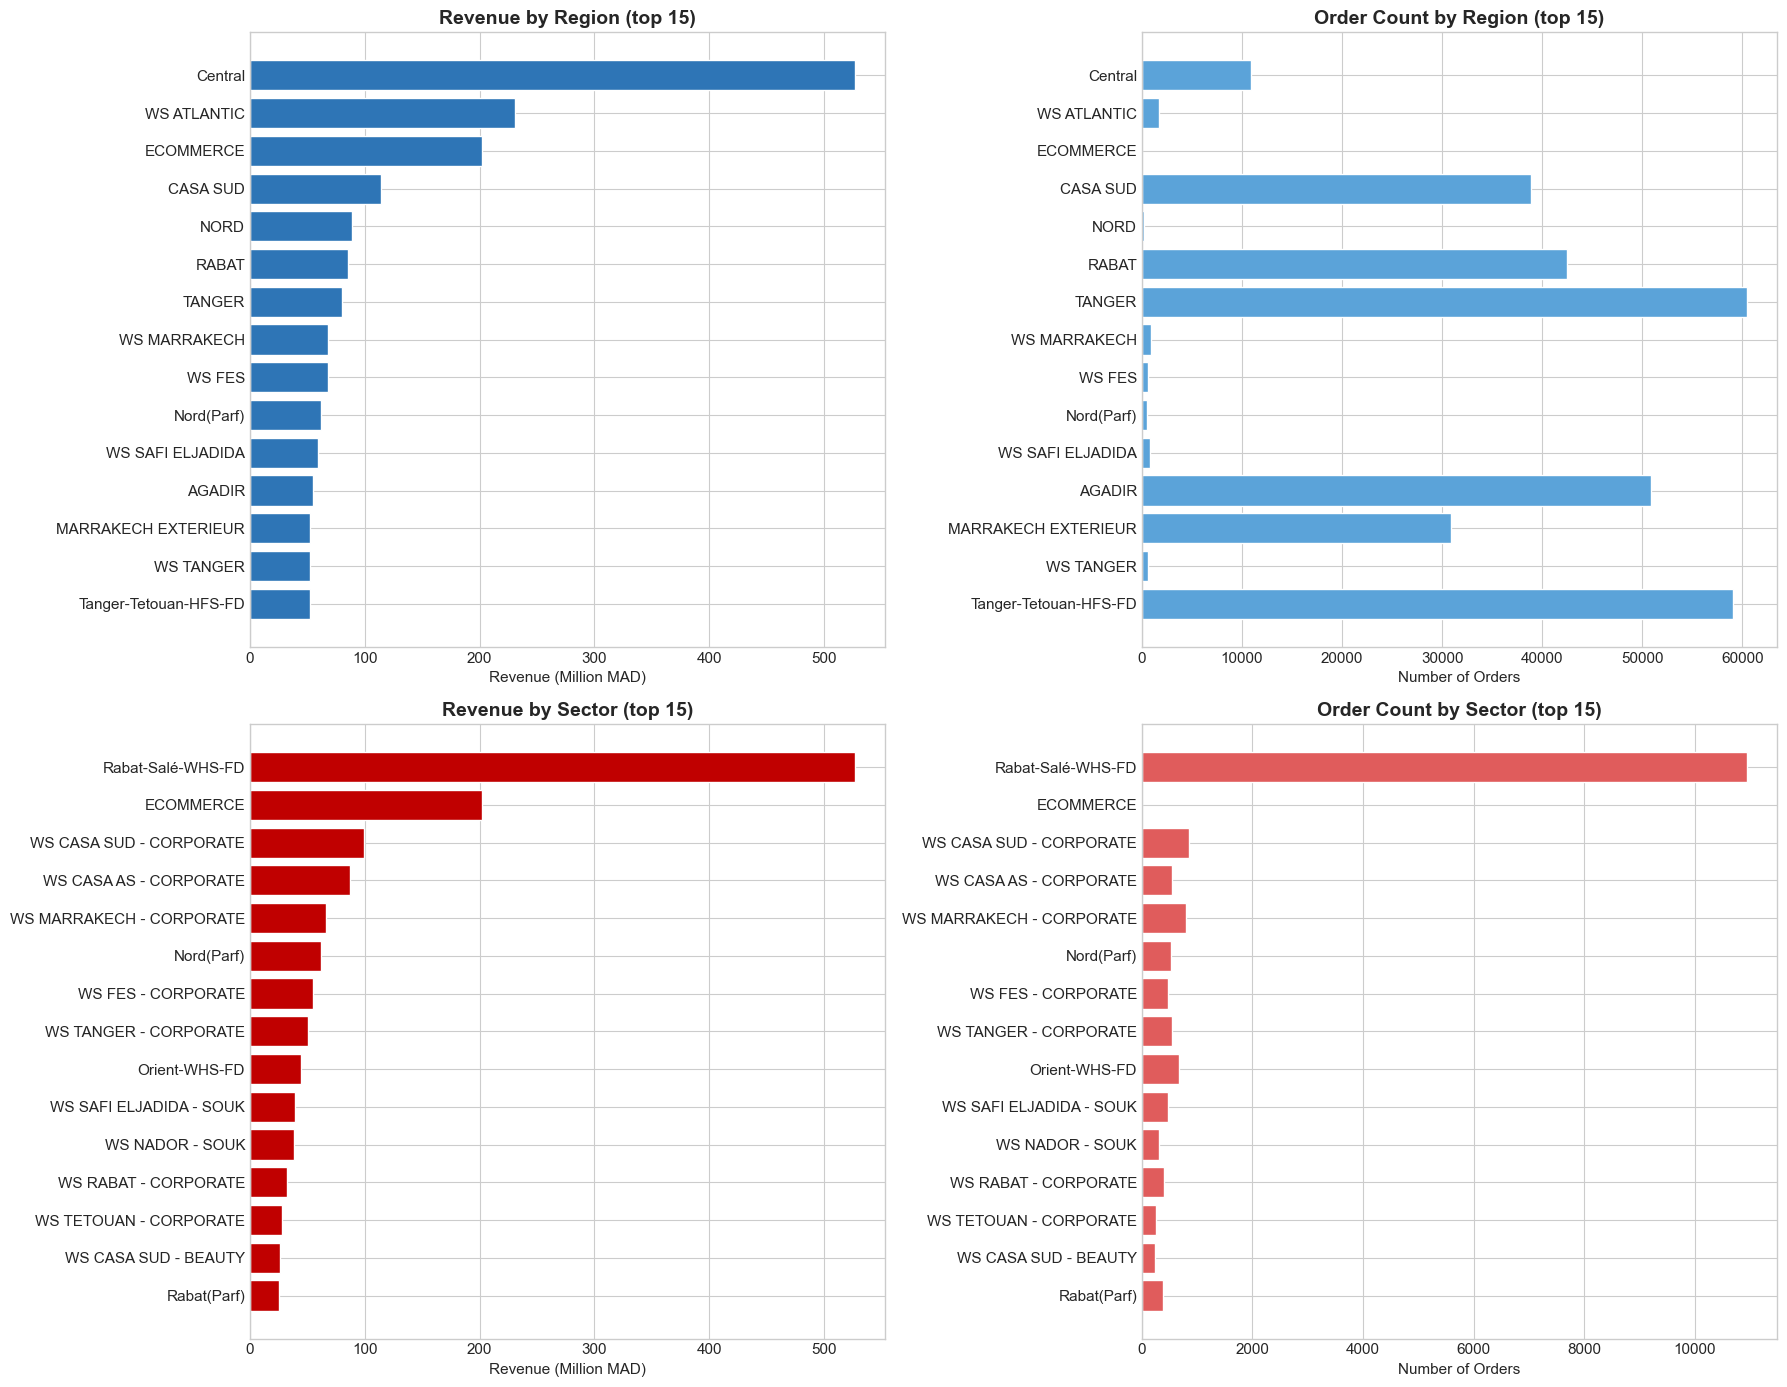

In [12]:
# Revenue and order count by Region and Sector
sales_by_region = (
    df_fact_sales
    .merge(df_dim_customer[['CustomerKey', 'RegionDescription']], on='CustomerKey')
    .groupby('RegionDescription')
    .agg(revenue=('LineTotalAmount', 'sum'), order_count=('SaleID', 'nunique'))
    .sort_values('revenue', ascending=False)
    .reset_index()
)

sales_by_sector = (
    df_fact_sales
    .merge(df_dim_customer[['CustomerKey', 'SectorDescription']], on='CustomerKey')
    .groupby('SectorDescription')
    .agg(revenue=('LineTotalAmount', 'sum'), order_count=('SaleID', 'nunique'))
    .sort_values('revenue', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Region — Revenue
r15 = sales_by_region.head(15)
axes[0, 0].barh(r15['RegionDescription'][::-1], r15['revenue'][::-1] / 1e6, color='#2E75B6', edgecolor='white')
axes[0, 0].set_title('Revenue by Region (top 15)', fontweight='bold')
axes[0, 0].set_xlabel('Revenue (Million MAD)')

# Region — Order Count
axes[0, 1].barh(r15['RegionDescription'][::-1], r15['order_count'][::-1], color='#5BA3D9', edgecolor='white')
axes[0, 1].set_title('Order Count by Region (top 15)', fontweight='bold')
axes[0, 1].set_xlabel('Number of Orders')

# Sector — Revenue
s15 = sales_by_sector.head(15)
axes[1, 0].barh(s15['SectorDescription'][::-1], s15['revenue'][::-1] / 1e6, color='#C00000', edgecolor='white')
axes[1, 0].set_title('Revenue by Sector (top 15)', fontweight='bold')
axes[1, 0].set_xlabel('Revenue (Million MAD)')

# Sector — Order Count
axes[1, 1].barh(s15['SectorDescription'][::-1], s15['order_count'][::-1], color='#e05c5c', edgecolor='white')
axes[1, 1].set_title('Order Count by Sector (top 15)', fontweight='bold')
axes[1, 1].set_xlabel('Number of Orders')

plt.tight_layout()
plt.show()


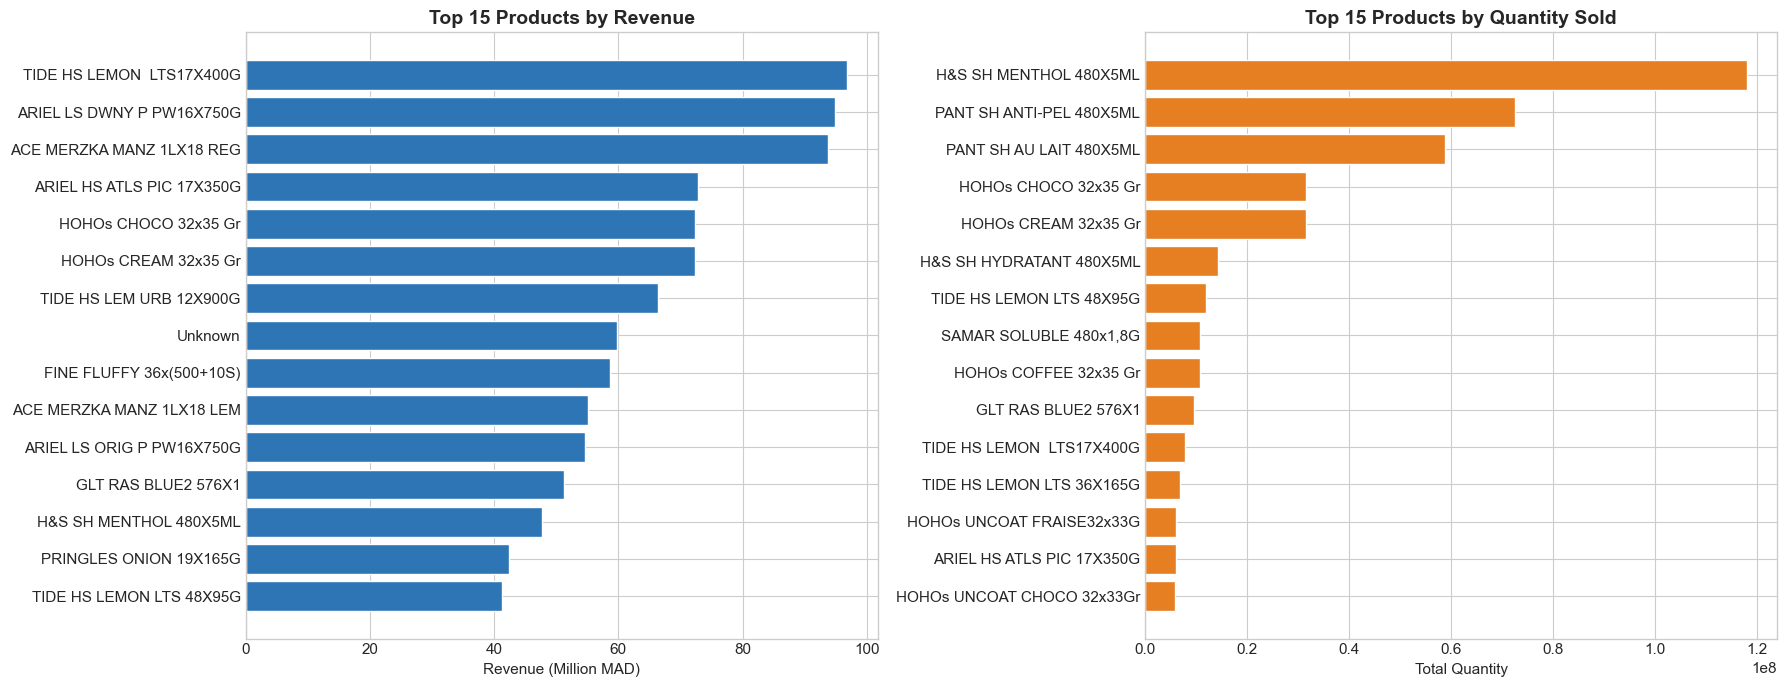

In [13]:
# Top products by revenue and quantity
sales_product = df_fact_sales.merge(
    df_dim_product[['ProductKey', 'ItemID', 'ProductName', 'Brand']], on='ProductKey'
)

top_by_revenue = (
    sales_product.groupby(['ItemID', 'ProductName'])
    .agg(revenue=('LineTotalAmount', 'sum'), qty=('Quantity', 'sum'))
    .sort_values('revenue', ascending=False)
    .head(15).reset_index()
)

top_by_qty = (
    sales_product.groupby(['ItemID', 'ProductName'])
    .agg(revenue=('LineTotalAmount', 'sum'), qty=('Quantity', 'sum'))
    .sort_values('qty', ascending=False)
    .head(15).reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Truncate long names
def short(name, n=30):
    return name[:n] + '…' if len(str(name)) > n else str(name)

# By revenue
labels_r = [short(n) for n in top_by_revenue['ProductName']][::-1]
axes[0].barh(labels_r, top_by_revenue['revenue'][::-1] / 1e6, color='#2E75B6', edgecolor='white')
axes[0].set_title('Top 15 Products by Revenue', fontweight='bold')
axes[0].set_xlabel('Revenue (Million MAD)')

# By quantity
labels_q = [short(n) for n in top_by_qty['ProductName']][::-1]
axes[1].barh(labels_q, top_by_qty['qty'][::-1], color='#e67e22', edgecolor='white')
axes[1].set_title('Top 15 Products by Quantity Sold', fontweight='bold')
axes[1].set_xlabel('Total Quantity')

plt.tight_layout()
plt.show()


<a id='5'></a>
## 5. Statistical Summaries and Distributions

Central tendency and spread for RFM and key measures; skewness; time distribution of sales; correlation matrix for R, F, M.

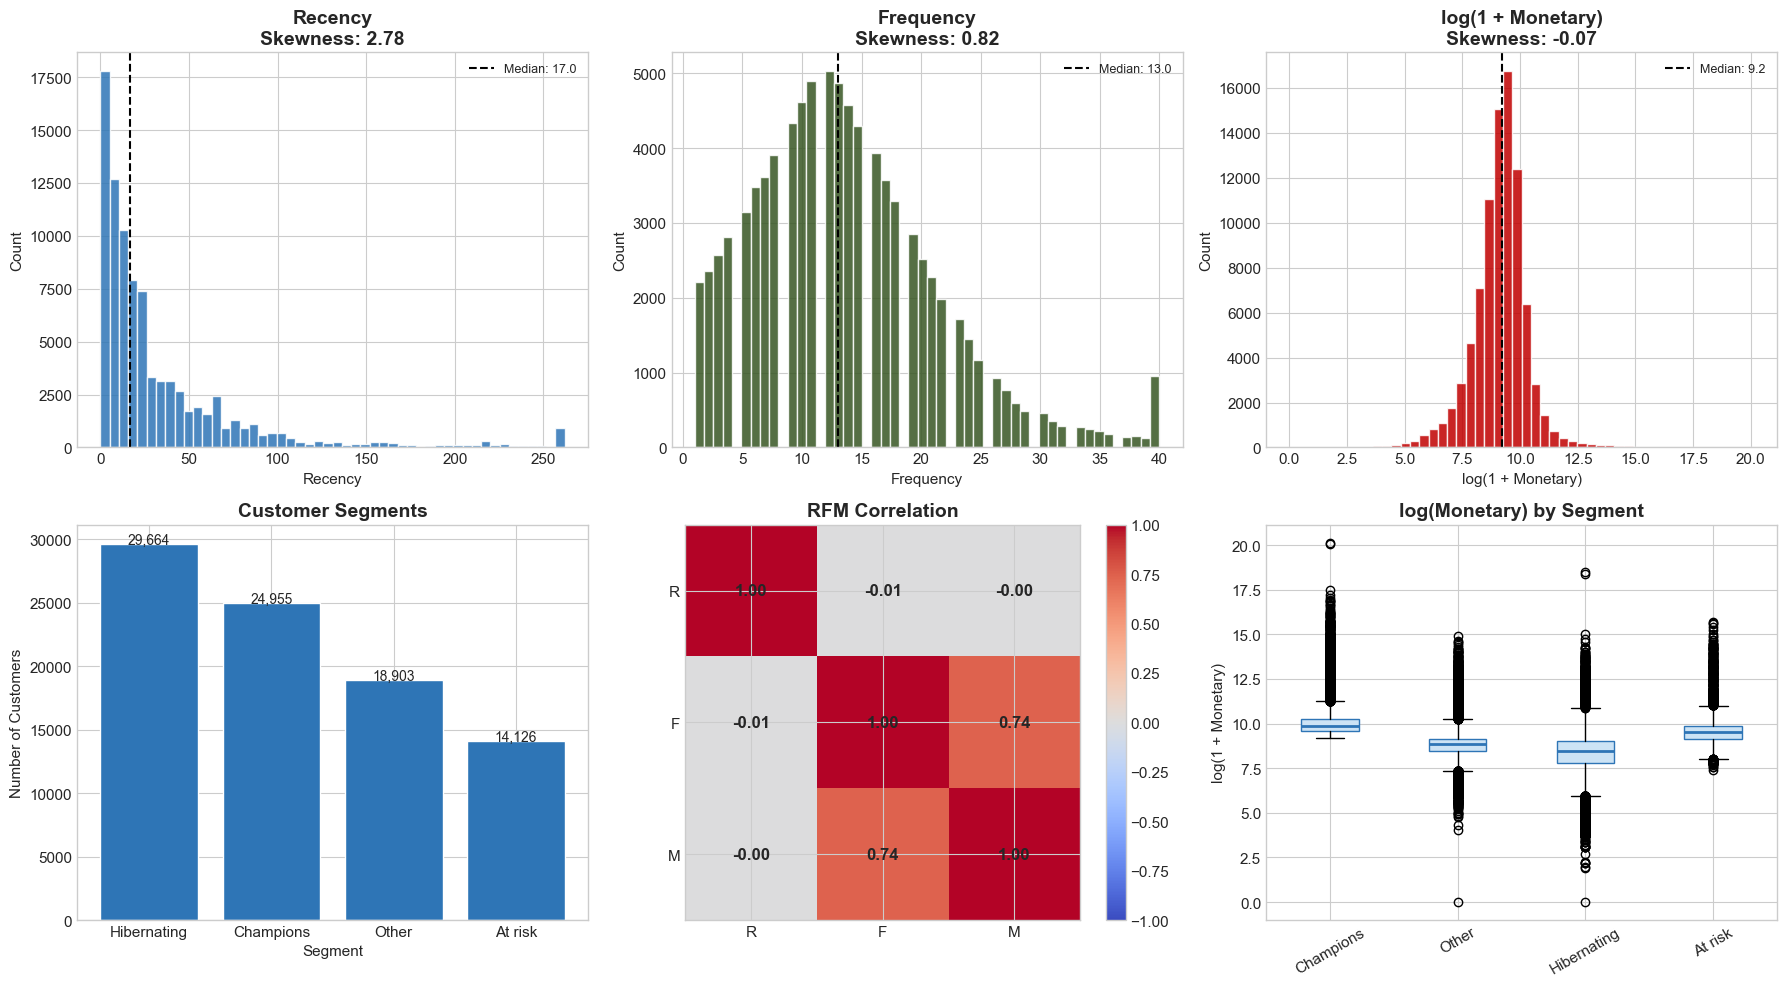

In [14]:
from scipy import stats

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

BLUE = '#2E75B6'

# Row 1: R, F, M histograms
for ax, col, color in zip(axes[0], ['Recency', 'Frequency', 'Monetary'], [BLUE, '#375623', '#C00000']):
    data = df_rfm[col].dropna()
    if col == 'Monetary':
        data = np.log1p(data)
        label = 'log(1 + Monetary)'
    else:
        data = data.clip(upper=data.quantile(0.99))
        label = col
    ax.hist(data, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.1f}')
    skew = stats.skew(data)
    ax.set_title(f'{label}\nSkewness: {skew:.2f}', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

# Row 2: Segment counts bar, RFM correlation heatmap, Monetary by segment box
seg_counts = df_rfm['Segment'].value_counts().sort_values(ascending=False)
axes[1, 0].bar(seg_counts.index, seg_counts.values, color=BLUE, edgecolor='white')
axes[1, 0].set_title('Customer Segments', fontweight='bold')
axes[1, 0].set_ylabel('Number of Customers')
axes[1, 0].set_xlabel('Segment')
for i, v in enumerate(seg_counts.values):
    axes[1, 0].text(i, v + 10, f'{v:,}', ha='center', fontsize=10)

corr = df_rfm[['Recency', 'Frequency', 'Monetary']].corr()
im = axes[1, 1].imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
axes[1, 1].set_xticks(range(3)); axes[1, 1].set_yticks(range(3))
axes[1, 1].set_xticklabels(['R', 'F', 'M']); axes[1, 1].set_yticklabels(['R', 'F', 'M'])
axes[1, 1].set_title('RFM Correlation', fontweight='bold')
for i in range(3):
    for j in range(3):
        axes[1, 1].text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=axes[1, 1])

df_rfm['Monetary_log'] = np.log1p(df_rfm['Monetary'])
segments = df_rfm['Segment'].unique()
data_box = [df_rfm[df_rfm['Segment'] == s]['Monetary_log'].dropna().values for s in segments]
axes[1, 2].boxplot(data_box, labels=segments, patch_artist=True,
                   boxprops=dict(facecolor='#cce3f5', color=BLUE),
                   medianprops=dict(color=BLUE, linewidth=2))
axes[1, 2].set_title('log(Monetary) by Segment', fontweight='bold')
axes[1, 2].set_ylabel('log(1 + Monetary)')
axes[1, 2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


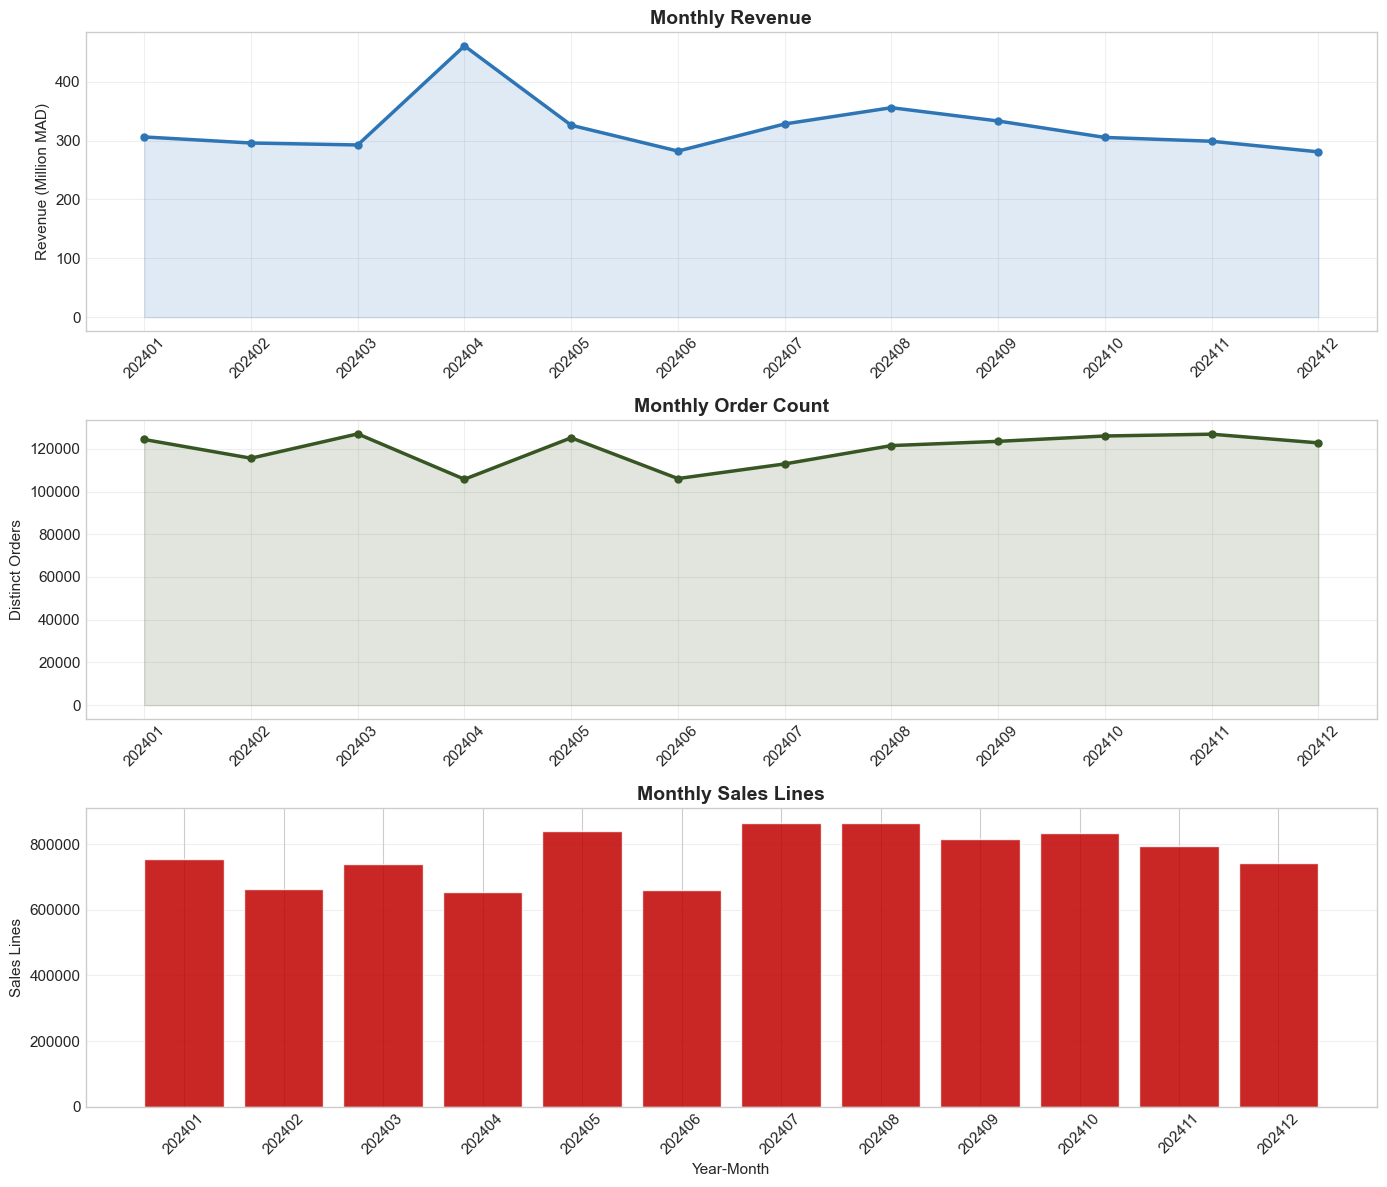

In [15]:
# Time distribution: sales by month
df_fact_sales['OrderYearMonth'] = (df_fact_sales['OrderDateKey'] // 100).astype(int)

monthly = (
    df_fact_sales.groupby('OrderYearMonth')
    .agg(
        revenue=('LineTotalAmount', 'sum'),
        order_count=('SaleID', 'nunique'),
        line_count=('SalesKey', 'count')
    )
    .reset_index()
)

x_labels = monthly['OrderYearMonth'].astype(str)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Revenue
axes[0].plot(x_labels, monthly['revenue'] / 1e6, color='#2E75B6', linewidth=2.5, marker='o', markersize=5)
axes[0].fill_between(x_labels, monthly['revenue'] / 1e6, alpha=0.15, color='#2E75B6')
axes[0].set_title('Monthly Revenue', fontweight='bold')
axes[0].set_ylabel('Revenue (Million MAD)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Order count
axes[1].plot(x_labels, monthly['order_count'], color='#375623', linewidth=2.5, marker='o', markersize=5)
axes[1].fill_between(x_labels, monthly['order_count'], alpha=0.15, color='#375623')
axes[1].set_title('Monthly Order Count', fontweight='bold')
axes[1].set_ylabel('Distinct Orders')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

# Line count
axes[2].bar(x_labels, monthly['line_count'], color='#C00000', edgecolor='white', alpha=0.85)
axes[2].set_title('Monthly Sales Lines', fontweight='bold')
axes[2].set_ylabel('Sales Lines')
axes[2].set_xlabel('Year-Month')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


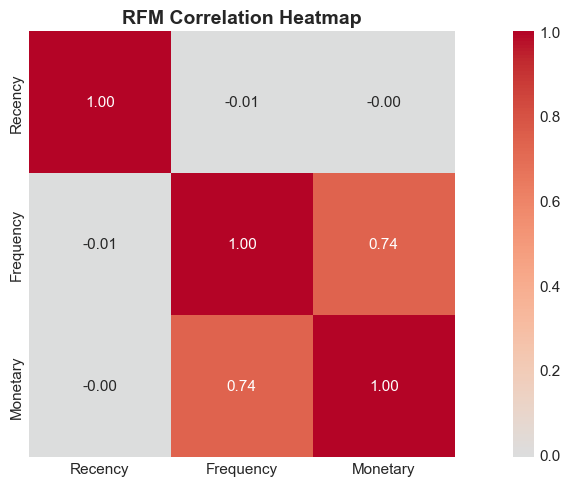

In [16]:
# RFM correlation matrix and heatmap
corr_rfm = df_rfm[['Recency', 'Frequency', 'Monetary']].corr().round(4).reset_index().rename(columns={'index': ''})

profile_dataframe('RFM Correlation Matrix', corr_rfm)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df_rfm[['Recency', 'Frequency', 'Monetary']].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('RFM Correlation Heatmap')
plt.tight_layout()
plt.show()


<a id='6'></a>
## 6. Visualizations

Bar charts (revenue/orders by region, sector, promo, payment method), time series (sales by month), box plots (Monetary by segment).

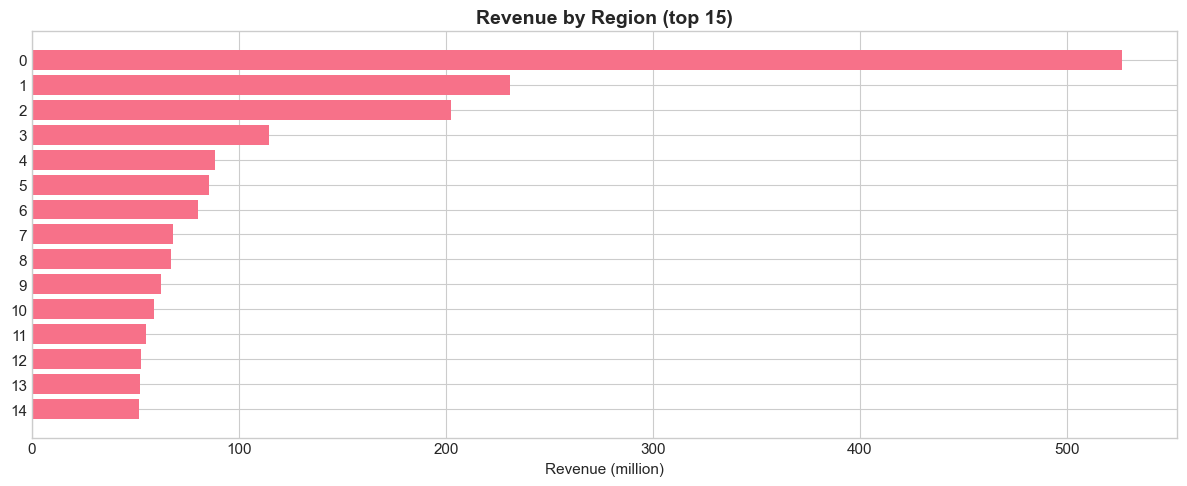

In [17]:
# Bar charts: revenue by region (top 15)
reg = sales_by_region.head(15)
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(reg.index.astype(str), reg['revenue'] / 1e6)
ax.set_xlabel('Revenue (million)')
ax.set_title('Revenue by Region (top 15)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

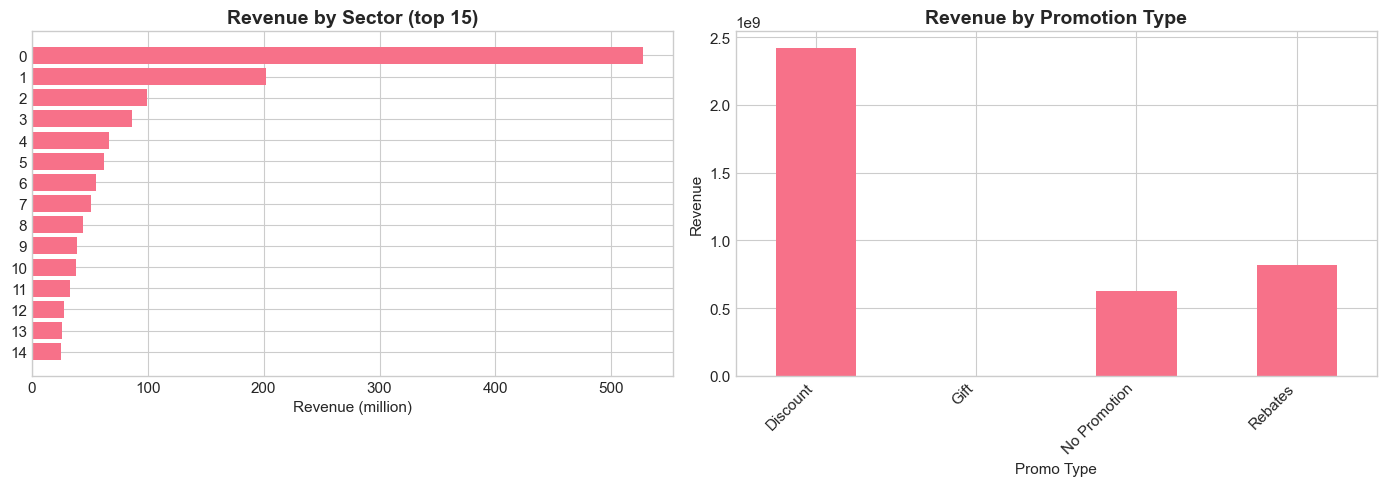

In [18]:
# Bar charts: revenue by sector (top 15) and by promotion type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sec = sales_by_sector.head(15)
axes[0].barh(sec.index.astype(str), sec['revenue'] / 1e6)
axes[0].set_xlabel('Revenue (million)')
axes[0].set_title('Revenue by Sector (top 15)')
axes[0].invert_yaxis()

promo_rev = df_fact_sales.merge(df_dim_promotion[['PromotionKey', 'PromoType']], on='PromotionKey').groupby('PromoType')['LineTotalAmount'].sum()
promo_rev.plot(kind='bar', ax=axes[1])
axes[1].set_xlabel('Promo Type')
axes[1].set_ylabel('Revenue')
axes[1].set_title('Revenue by Promotion Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

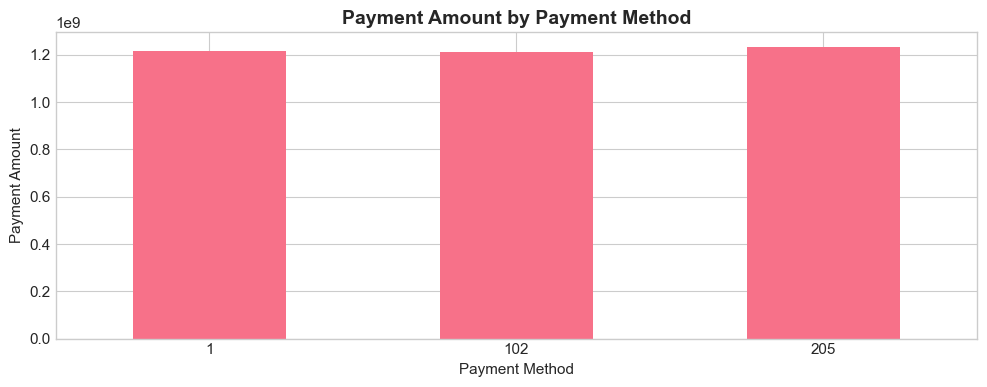

In [19]:
# Revenue by payment method (from FactInvoices)
pay_rev = df_fact_invoices.merge(df_dim_payment[['PaymentMethodKey', 'PaymentMethodCode']], on='PaymentMethodKey').groupby('PaymentMethodCode')['PaymentAmount'].sum()
pay_rev.plot(kind='bar', figsize=(10, 4))
plt.xlabel('Payment Method')
plt.ylabel('Payment Amount')
plt.title('Payment Amount by Payment Method')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

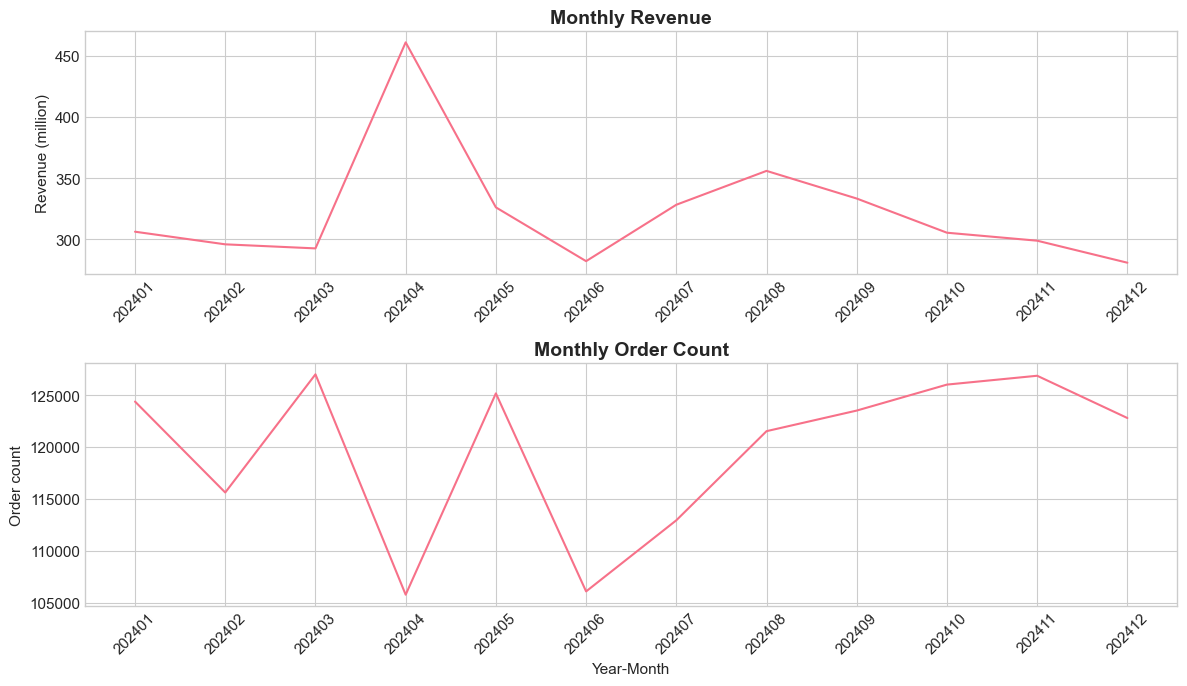

In [20]:
# Time series: revenue and order count by month
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(monthly['OrderYearMonth'].astype(str), monthly['revenue'] / 1e6)
axes[0].set_ylabel('Revenue (million)')
axes[0].set_title('Monthly Revenue')
axes[0].tick_params(axis='x', rotation=45)
axes[1].plot(monthly['OrderYearMonth'].astype(str), monthly['order_count'])
axes[1].set_ylabel('Order count')
axes[1].set_xlabel('Year-Month')
axes[1].set_title('Monthly Order Count')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

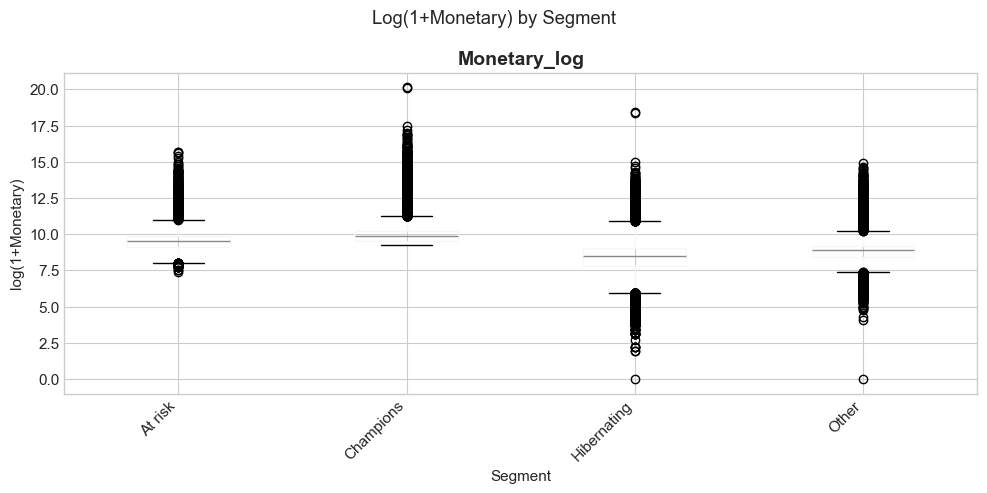

In [21]:
# Box plot: Monetary by RFM Segment
df_rfm['Monetary_log'] = np.log1p(df_rfm['Monetary'])
df_rfm.boxplot(column='Monetary_log', by='Segment', figsize=(10, 5))
plt.suptitle('Log(1+Monetary) by Segment')
plt.xlabel('Segment')
plt.ylabel('log(1+Monetary)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<a id='7'></a>
## 7. Conclusion & Next Steps

**Findings:**
- The data warehouse is fully loaded; all 8 star tables are populated and FKs are consistent.
- RFM distributions show typical patterns: Recency and Frequency are right-skewed; Monetary is highly skewed (log scale helps).
- Segment sizes (Champions, Loyal, At risk, Hibernating) give a first view of customer base health.
- Revenue and orders vary by region, sector, promotion type, and payment method; time series show trends by month.

**Next steps (Phase 3):**
- Use `df_rfm` (and optionally persist it to CSV/Parquet) for **customer segmentation** (e.g. K-Means, DBSCAN) and **churn prediction** (e.g. XGBoost, Random Forest).
- Refine segments and interpret them for business; then move to CLV prediction and dashboards (Phase 4).

In [22]:
# Optional: persist RFM for Phase 3 (segmentation, churn)
# out_dir = PROJECT_ROOT / 'Data' / 'rfm'
# out_dir.mkdir(parents=True, exist_ok=True)
# df_rfm.to_csv(out_dir / 'rfm_customers.csv', index=False)
# print('Saved df_rfm to', out_dir / 'rfm_customers.csv')